# ASSIGNMENT - 3
# NAME: A.S.TRITTHIK THILAGAR
# REGNO: 3122237001057

# CLASSIFICATION PROBLEM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outliers managed.
Applying StandardScaler based on model type: GaussianNB

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.87 ± 0.01
Precision: 0.82 ± 0.02
Recall: 0.86 ± 0.02
F1 Score: 0.84 ± 0.01

--- Model Performance ---
Accuracy: 0.87
Precision: 0.84
Recall: 0.85
F1 Score: 0.84

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       531
           1       0.84      0.85      0.84       390

    accuracy                           0.87       921
   macro avg       0.86      0.86      0.86       921
weighted avg       0.87      0.87      0.87       921



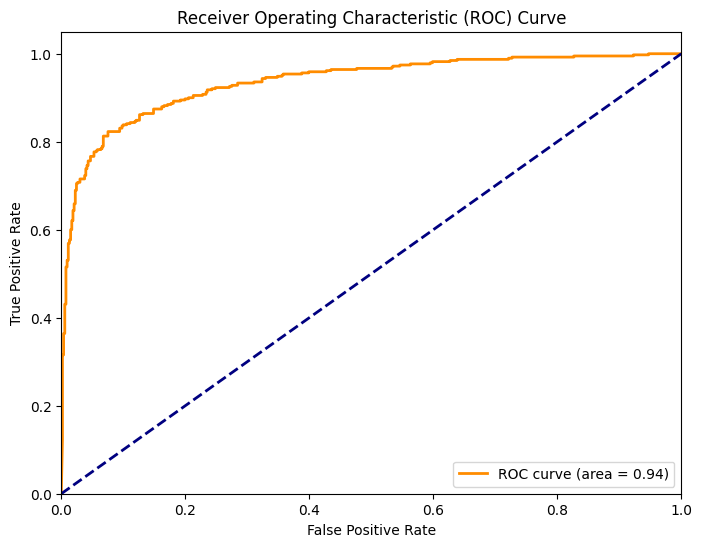


--- Plotting Confusion Matrix ---


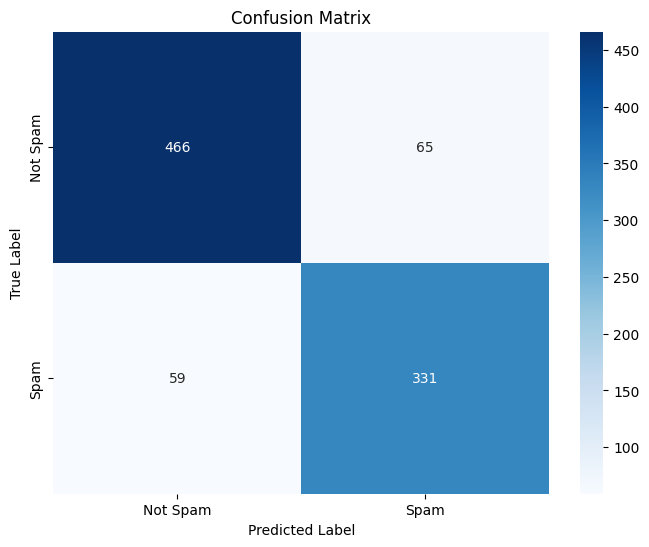

In [ ]:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
from google.colab import drive
from sklearn.metrics import confusion_matrix

# 2. Importing the Dataset
# Replace 'your_dataset.csv' with your file path
'''df = pd.read_csv('your_dataset.csv')'''

drive.mount('/content/drive')
train_path = '/content/drive/MyDrive/Colab Notebooks/Templates_ML/spambase.csv'
train_df = pd.read_csv(train_path)

# Assume 'target' is the name of your target variable column
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
#categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Handle numerical missing values with the mean
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].mean())

'''# Handle categorical missing values with the mode
for col in categorical_cols:
    mode_value = X[col].mode()[0]
    X[col].fillna(mode_value, inplace=True)'''

# --- Outlier Management (Capping with IQR method) ---
for col in numerical_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
print("Outliers managed.")

# 4. Splitting the Dataset
# 1. First split: Create the training (80%) and test (20%) sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Second split: Split the full training set into a smaller training set and a validation set
# We'll use 25% of the full training set for validation (0.25 * 0.8 = 0.2 of the original data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42 # 0.25 x 0.8 = 0.2
)

# --- Standardization ---
# Note: Fit the scaler ONLY on the training data to avoid data leakage
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

def choose_scaler(model):
    if isinstance(model, (GaussianNB, LogisticRegression, Ridge, Lasso, SVC,KNeighborsClassifier)):
        return StandardScaler()
    elif isinstance(model, (MultinomialNB, BernoulliNB)):
        return MinMaxScaler()
    elif isinstance(model, (DecisionTreeClassifier, RandomForestClassifier)):
        return None  # Tree-based models don't need scaling
    else:
        print("Unknown model type — defaulting to MinMaxScaler.")
        return MinMaxScaler()

def auto_scale_model_data(model, X_train, X_test, X_val, X_train_full, numerical_cols):
    scaler = choose_scaler(model)

    if scaler is None:
        print("No scaling applied for tree-based model.")
        return X_train.copy(), X_test.copy(), X_val.copy(), X_train_full.copy()

    print(f"Applying {scaler.__class__.__name__} based on model type: {model.__class__.__name__}")

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_val_scaled = X_val.copy()
    X_train_full_scaled = X_train_full.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_train_full_scaled[numerical_cols] = scaler.transform(X_train_full[numerical_cols])

    return X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled



from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = GaussianNB()

X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_cv, X_train, X_test, X_val, X_train_full, numerical_cols
)

print("\n--- Cross-Validation Scores (on training set) ---")

# Accuracy
cv_accuracy = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

# Precision
cv_precision = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

# Recall
cv_recall = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

# F1 Score
cv_f1 = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")


# 5. MODEL BUILDING
# NAIVE BAYES

model = GaussianNB()
model.fit(X_train_full_scaled, y_train_full)

# --- Make predictions on the test set ---
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

# 6. PERFORMANCE EVALUATION
print("\n--- Model Performance ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
#
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
#
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
#
# # --- Plotting ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
#
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print("\n--- Plotting Confusion Matrix ---")

# 7. PLOT CONFUSION MATRIX
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Applying MinMaxScaler based on model type: MultinomialNB
Multinomial Naive Bayes model cross validation(on training set)
Accuracy: 0.86 ± 0.01
Precision: 0.87 ± 0.02
Recall: 0.75 ± 0.03
F1 Score: 0.80 ± 0.01

--- MultinomialNB Model Performance ---
Accuracy: 0.86
Precision: 0.88
Recall: 0.76
F1 Score: 0.82

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       531
           1       0.88      0.76      0.82       390

    accuracy                           0.86       921
   macro avg       0.86      0.84      0.85       921
weighted avg       0.86      0.86      0.85       921



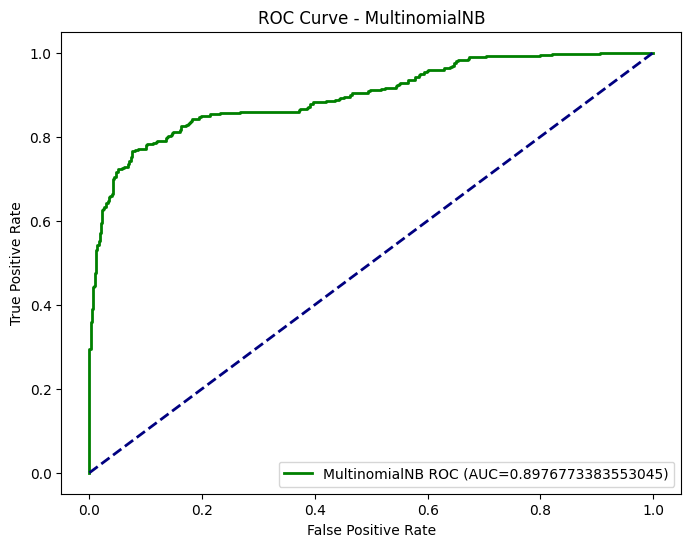

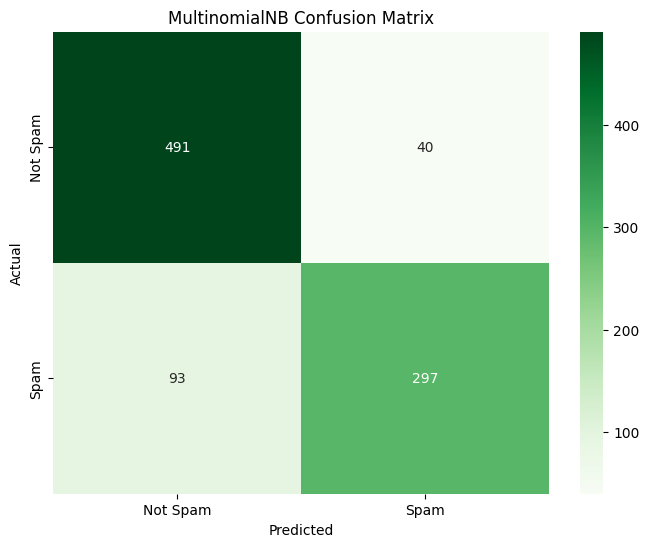

In [ ]:
# MULTINOMIAL NAIVE BAYES
from sklearn.naive_bayes import MultinomialNB
model_multi = MultinomialNB()

X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_multi, X_train, X_test, X_val, X_train_full, numerical_cols
)
print("Multinomial Naive Bayes model cross validation(on training set)")
#Accuracy
cv_accuracy=cross_val_score(model_multi , X_train_full_scaled,y_train_full,cv=cv,scoring='accuracy')
print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

# Precision
cv_precision = cross_val_score(model_multi, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

# Recall
cv_recall = cross_val_score(model_multi, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

# F1
cv_f1 = cross_val_score(model_multi, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

model_multi.fit(X_train_full_scaled,y_train_full)
y_pred_multi=model_multi.predict(X_test_scaled)
y_pred_proba_multi=model_multi.predict_proba(X_test_scaled)[:,1]

print("\n--- MultinomialNB Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_multi):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_multi):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_multi):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred_multi):.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_multi))

fpr,tpr,_=roc_curve(y_test , y_pred_proba_multi)
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='green',lw=2,label=f'MultinomialNB ROC (AUC={roc_auc})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MultinomialNB')
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred_multi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('MultinomialNB Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Applying MinMaxScaler based on model type: BernoulliNB

--- BernoulliNB: Cross-Validation Scores (on training set) ---
Accuracy: 0.81 ± 0.01
Precision: 0.75 ± 0.01
Recall: 0.79 ± 0.03
F1 Score: 0.77 ± 0.02

--- BernoulliNB Model Performance ---
Accuracy: 0.80
Precision: 0.77
Recall: 0.76
F1 Score: 0.77

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       531
           1       0.77      0.76      0.77       390

    accuracy                           0.80       921
   macro avg       0.80      0.80      0.80       921
weighted avg       0.80      0.80      0.80       921



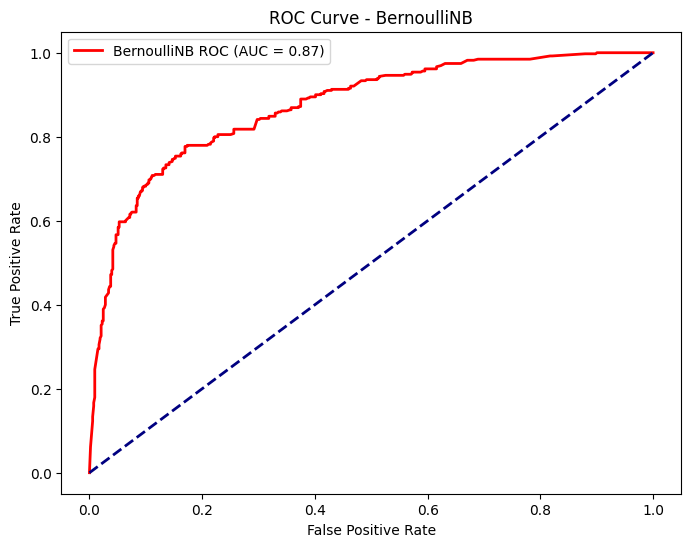

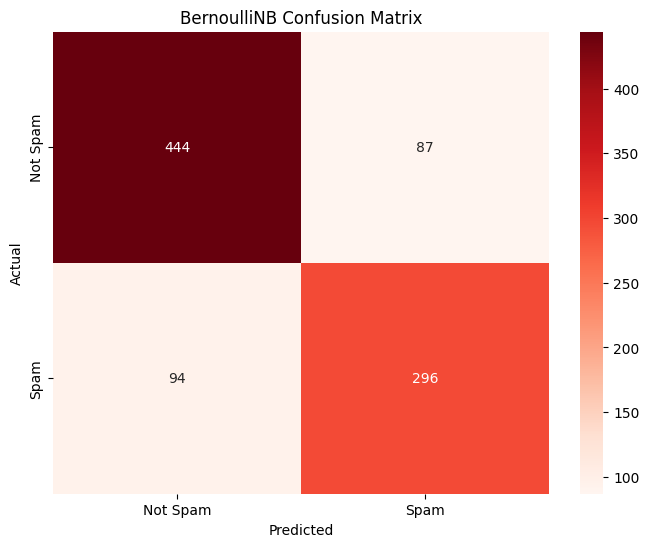

In [ ]:
model_bern = BernoulliNB()
X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_bern, X_train, X_test, X_val, X_train_full, numerical_cols
)
print("\n--- BernoulliNB: Cross-Validation Scores (on training set) ---")

cv_accuracy = cross_val_score(model_bern, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

cv_precision = cross_val_score(model_bern, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

cv_recall = cross_val_score(model_bern, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

cv_f1 = cross_val_score(model_bern, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

model_bern.fit(X_train_full_scaled, y_train_full)
y_pred_bern = model_bern.predict(X_test_scaled)
y_pred_proba_bern = model_bern.predict_proba(X_test_scaled)[:, 1]

print("\n--- BernoulliNB Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bern):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_bern):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_bern):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred_bern):.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bern))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_bern)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'BernoulliNB ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BernoulliNB')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bern)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('BernoulliNB Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

K =3
Applying StandardScaler based on model type: KNeighborsClassifier

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.89 ± 0.01
Precision: 0.88 ± 0.01
Recall: 0.83 ± 0.03
F1 Score: 0.86 ± 0.02

--- Model Performance ---
Accuracy: 0.90
Precision: 0.90
Recall: 0.86
F1 Score: 0.88

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92       531
           1       0.90      0.86      0.88       390

    accuracy                           0.90       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.90      0.90      0.90       921



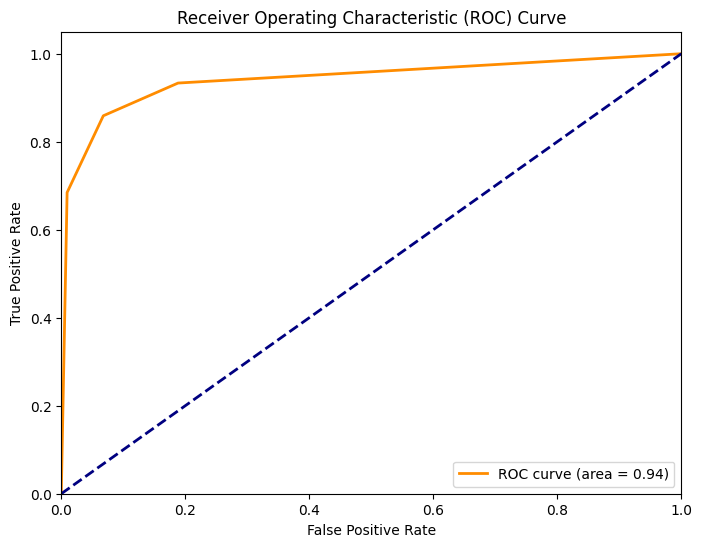


--- Plotting Confusion Matrix ---


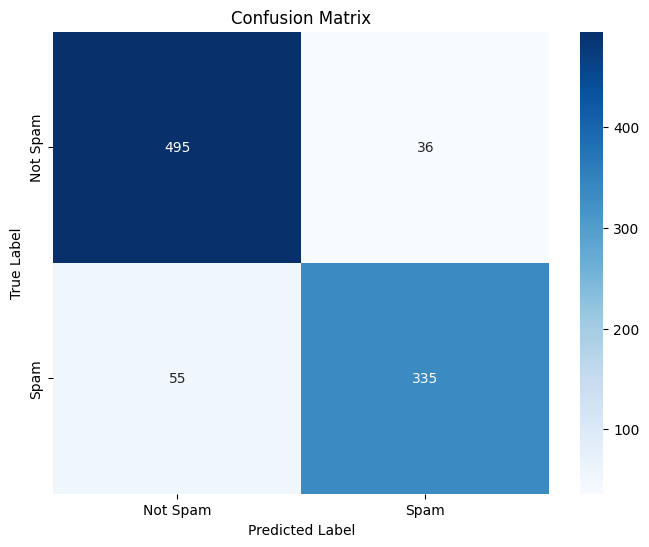

K =5
Applying StandardScaler based on model type: KNeighborsClassifier

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.89 ± 0.01
Precision: 0.89 ± 0.02
Recall: 0.82 ± 0.04
F1 Score: 0.86 ± 0.02

--- Model Performance ---
Accuracy: 0.90
Precision: 0.92
Recall: 0.83
F1 Score: 0.87

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       531
           1       0.92      0.83      0.87       390

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



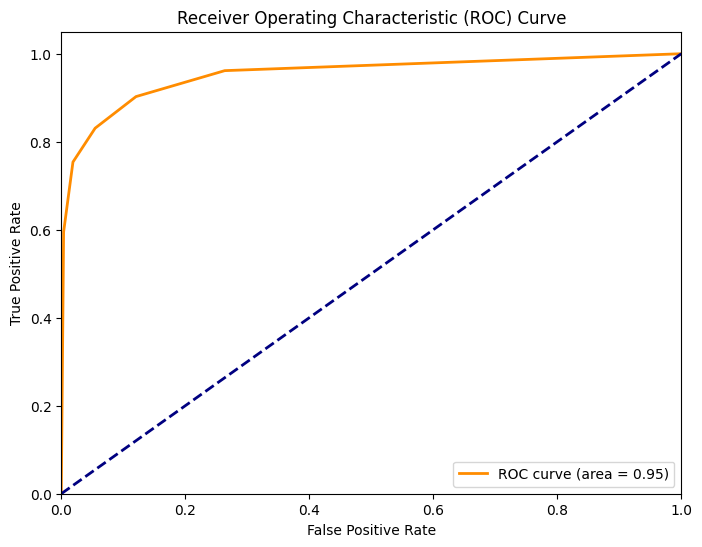


--- Plotting Confusion Matrix ---


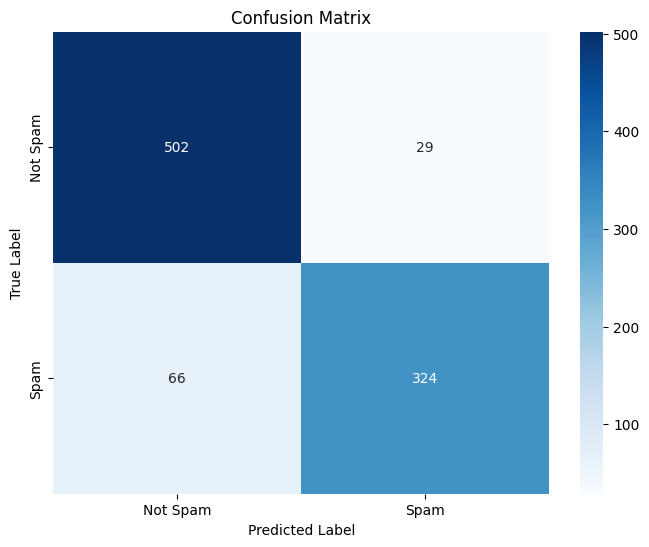

K =10
Applying StandardScaler based on model type: KNeighborsClassifier

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.89 ± 0.02
Precision: 0.92 ± 0.01
Recall: 0.79 ± 0.04
F1 Score: 0.85 ± 0.02

--- Model Performance ---
Accuracy: 0.91
Precision: 0.96
Recall: 0.82
F1 Score: 0.88

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       531
           1       0.96      0.82      0.88       390

    accuracy                           0.91       921
   macro avg       0.92      0.90      0.90       921
weighted avg       0.91      0.91      0.91       921



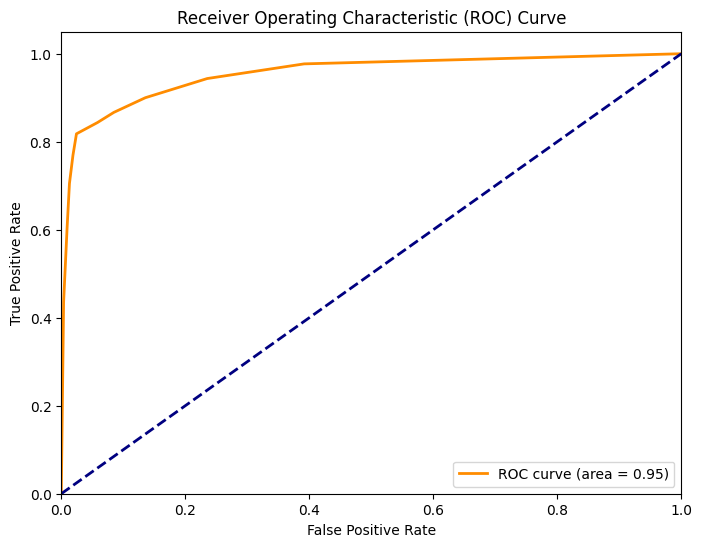


--- Plotting Confusion Matrix ---


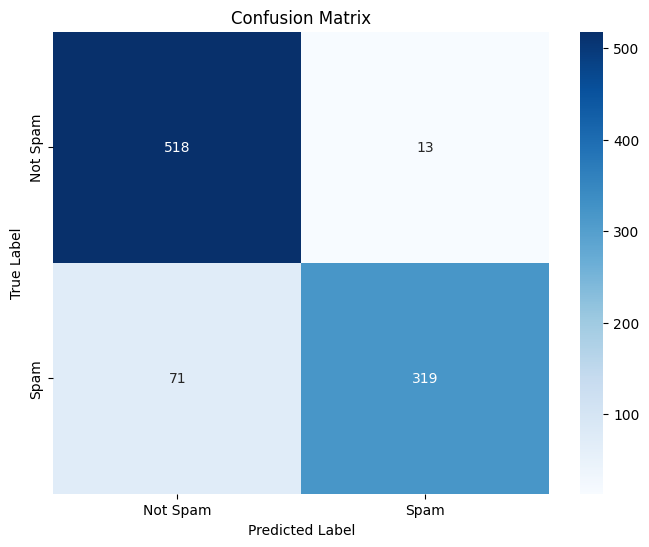

In [ ]:
# MODEL BUILDING USING KNN
import time
from sklearn.model_selection import cross_val_score, StratifiedKFold
for k in [3,5,10]:
  # Cross-validation setup
  print(f"K ={k}")
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  model_cv = KNeighborsClassifier(n_neighbors=k)

  X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
      model_cv, X_train, X_test, X_val, X_train_full, numerical_cols
  )

  print("\n--- Cross-Validation Scores (on training set) ---")

  # Accuracy
  cv_accuracy = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
  print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

  # Precision
  cv_precision = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
  print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

  # Recall
  cv_recall = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
  print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

  # F1 Score
  cv_f1 = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
  print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

  if(k==5):
    start_knn=time.perf_counter()
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_full_scaled, y_train_full)
  if(k==5):
    end_knn=time.perf_counter()

  # --- Make predictions on the test set ---
  y_pred = model.predict(X_test_scaled)
  y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

  # 6. PERFORMANCE EVALUATION
  # --- This part assumes `y_pred` and `y_pred_proba` are defined from your model's predictions ---
  print("\n--- Model Performance ---")
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  #
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 Score: {f1:.2f}")
  #
  print("\nClassification Report:\n")
  print(classification_report(y_test, y_pred))
  #
  # # --- Plotting ROC Curve ---
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
  roc_auc = auc(fpr, tpr)
  #
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()

  print("\n--- Plotting Confusion Matrix ---")

  # 7. PLOT CONFUSION MATRIX
  # Generate the confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  # Visualize the confusion matrix using a heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Not Spam', 'Spam'],
              yticklabels=['Not Spam', 'Spam'])

  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

Applying StandardScaler based on model type: KNeighborsClassifier

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.89 ± 0.01
Precision: 0.89 ± 0.02
Recall: 0.82 ± 0.04
F1 Score: 0.86 ± 0.02

--- Model Performance ---
Accuracy: 0.90
Precision: 0.92
Recall: 0.83
F1 Score: 0.87

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       531
           1       0.92      0.83      0.87       390

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



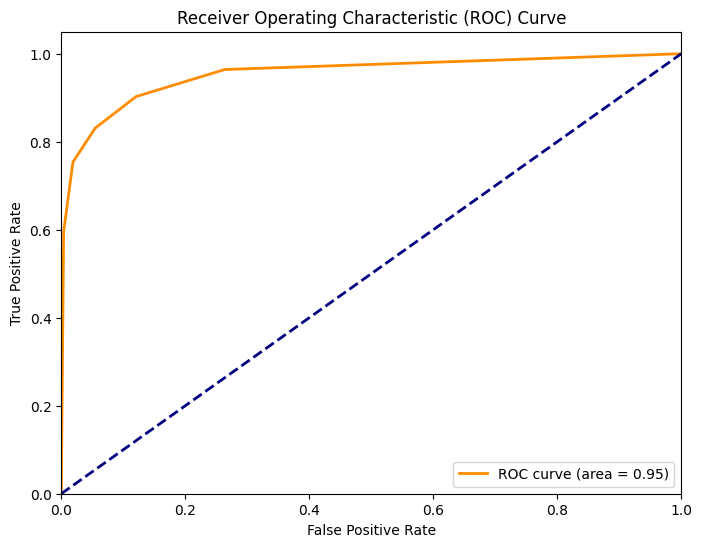


--- Plotting Confusion Matrix ---


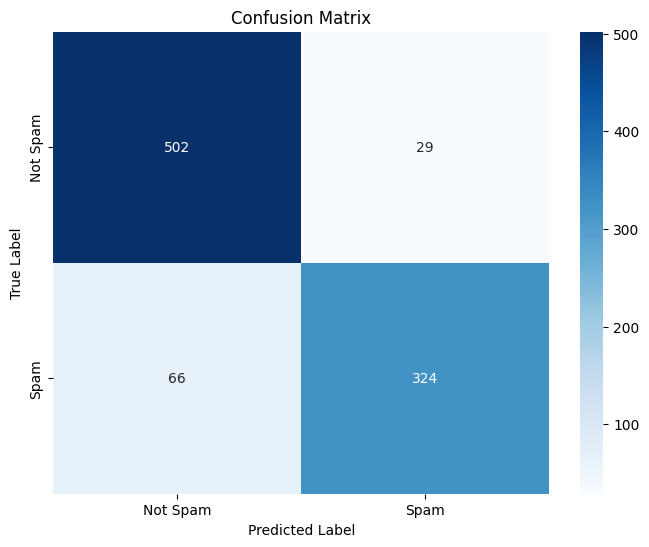

In [ ]:
# MODEL BUILDING USING KNN - KD TREE
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree')

X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_cv, X_train, X_test, X_val, X_train_full, numerical_cols
)

print("\n--- Cross-Validation Scores (on training set) ---")

# Accuracy
cv_accuracy = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

# Precision
cv_precision = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

# Recall
cv_recall = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

# F1 Score
cv_f1 = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

start_knn_kd=time.perf_counter()
model = KNeighborsClassifier(n_neighbors=5 , algorithm='kd_tree')
model.fit(X_train_full_scaled, y_train_full)
end_knn_kd = time.perf_counter()

# --- Make predictions on the test set ---
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

# 6. PERFORMANCE EVALUATION
# --- This part assumes `y_pred` and `y_pred_proba` are defined from your model's predictions ---
print("\n--- Model Performance ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
#
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
#
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
#
# # --- Plotting ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
#
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print("\n--- Plotting Confusion Matrix ---")

# 7. PLOT CONFUSION MATRIX
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Applying StandardScaler based on model type: KNeighborsClassifier

--- Cross-Validation Scores (on training set) ---
Accuracy: 0.89 ± 0.01
Precision: 0.89 ± 0.02
Recall: 0.82 ± 0.04
F1 Score: 0.86 ± 0.02

--- Model Performance ---
Accuracy: 0.90
Precision: 0.92
Recall: 0.83
F1 Score: 0.87

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       531
           1       0.92      0.83      0.87       390

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



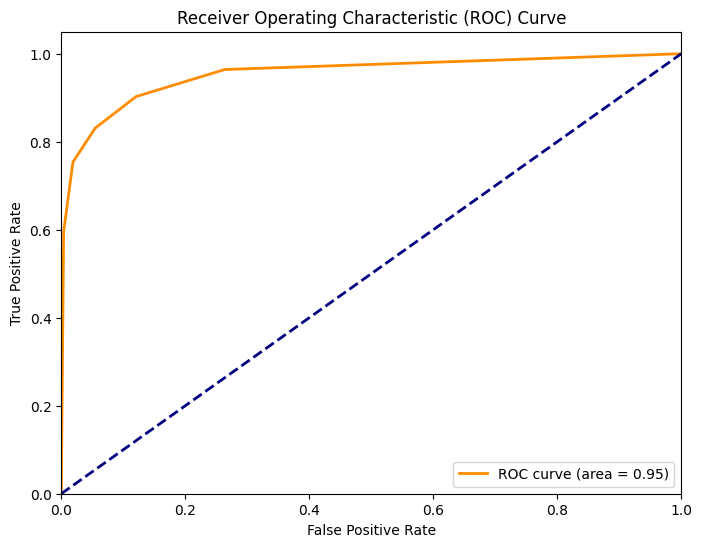


--- Plotting Confusion Matrix ---


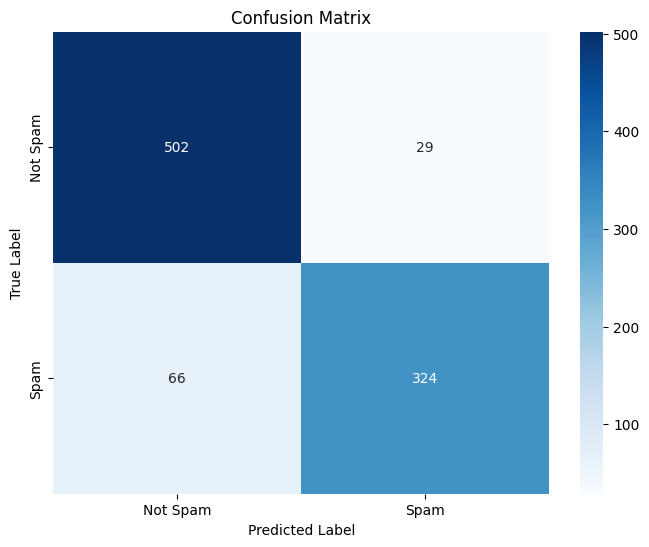

In [ ]:
# MODEL BUILDING USING KNN - Ball TREE
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = KNeighborsClassifier(n_neighbors=5,algorithm='ball_tree')

X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_cv, X_train, X_test, X_val, X_train_full, numerical_cols
)

print("\n--- Cross-Validation Scores (on training set) ---")

# Accuracy
cv_accuracy = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

# Precision
cv_precision = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")

# Recall
cv_recall = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")

# F1 Score
cv_f1 = cross_val_score(model_cv, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

start_knn_ball=time.perf_counter()
model = KNeighborsClassifier(n_neighbors=5 , algorithm='ball_tree')
model.fit(X_train_full_scaled, y_train_full)
end_knn_ball=time.perf_counter()

# --- Make predictions on the test set ---
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

# 6. PERFORMANCE EVALUATION
# --- This part assumes `y_pred` and `y_pred_proba` are defined from your model's predictions ---
print("\n--- Model Performance ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
#
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
#
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
#
# # --- Plotting ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
#
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print("\n--- Plotting Confusion Matrix ---")

# 7. PLOT CONFUSION MATRIX
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print('COMPARISON BETWEEN KNN , KNN-KD TREE AND KNN-BALL TREE ( BY TIME)')
print(f"KNN training time: {end_knn - start_knn:.4f} seconds")
print(f"KNN KD TREE training time: {end_knn_kd - start_knn_kd:.4f} seconds")
print(f"KNN BALL TREE training time: {end_knn_ball - start_knn_ball:.4f} seconds")

COMPARISON BETWEEN KNN , KNN-KD TREE AND KNN-BALL TREE ( BY TIME)
KNN training time: 0.0079 seconds
KNN KD TREE training time: 0.0397 seconds
KNN BALL TREE training time: 0.0310 seconds


# FINDING THE BEST MODEL BASED ON HYPER PARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define model
model = KNeighborsClassifier()

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'leaf_size': [20, 30, 40]
}

# Set up grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_full_scaled, y_train_full)

# Best parameters and score
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Params: {'algorithm': 'ball_tree', 'leaf_size': 20, 'n_neighbors': 7, 'weights': 'distance'}
Best Score: 0.9089673913043479


Mounted at /content/drive
Outliers managed.
Fitting 5 folds for each of 24 candidates, totalling 120 fits

--- Best Parameters ---
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9073

--- Model Performance ---
Accuracy: 0.91
Precision: 0.93
Recall: 0.85
F1 Score: 0.88

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       531
           1       0.93      0.85      0.88       390

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.90       921
weighted avg       0.91      0.91      0.91       921



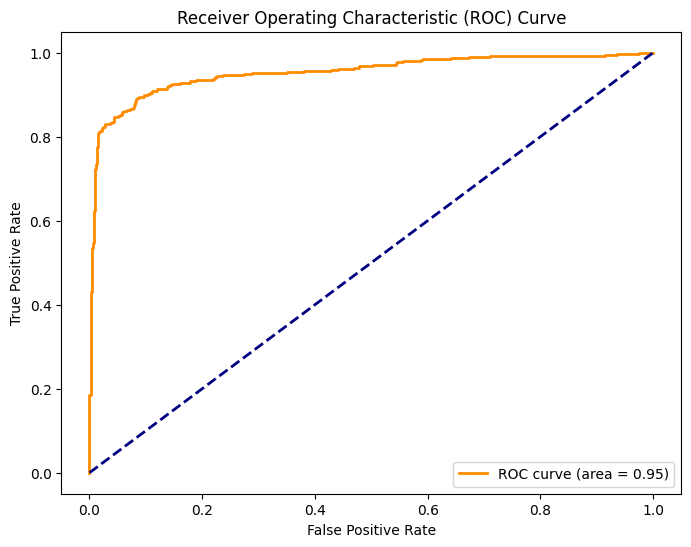

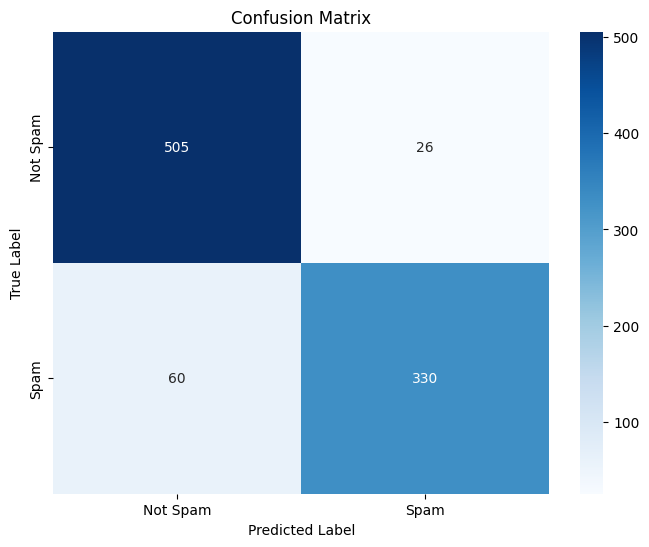

In [ ]:
#SVM CLASSIFIER:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, confusion_matrix
from sklearn.svm import SVC
from google.colab import drive

# 2. Importing the Dataset
drive.mount('/content/drive')
train_path = '/content/drive/MyDrive/Colab Notebooks/Templates_ML/spambase.csv'
train_df = pd.read_csv(train_path)

# Features and target
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]

# Identify numerical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Handle numerical missing values with mean
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].mean())

# --- Outlier Management (IQR capping) ---
for col in numerical_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])

print("Outliers managed.")

# 3. Splitting Data
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

# --- Standardization for SVM ---
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_val_scaled = X_val.copy()
X_train_full_scaled = X_train_full.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_train_full_scaled[numerical_cols] = scaler.transform(X_train_full[numerical_cols])

# 4. Hyperparameter tuning with GridSearchCV
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_model = SVC(probability=True)

grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_full_scaled, y_train_full)

print("\n--- Best Parameters ---")
print(grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# 5. Train final SVM with best params
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_full_scaled, y_train_full)

# 6. Evaluate on test data
y_pred = best_svm.predict(X_test_scaled)
y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 7. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
